
# Level 1 - Task 3

## Geospatial Analysis

### Objective

The objective of this task is to perform geospatial analysis of restaurant locations using latitude and longitude coordinates.

The analysis includes:

- Visualizing restaurant locations on an interactive map.
- Analyzing restaurant distribution across countries and cities.
- Studying the relationship between restaurant locations and aggregate ratings.
- Drawing business insights from geographical patterns.

In [97]:
!pip install folium

In [98]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import folium
from folium.plugins import MarkerCluster

sns.set_theme(style="whitegrid")

In [99]:
df = pd.read_csv("/Cleaned_Dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [100]:
# Map country codes to country names

country_mapping = {
    1: "India",
    14: "Australia",
    30: "Brazil",
    37: "Canada",
    94: "Indonesia",
    148: "New Zealand",
    162: "Philippines",
    166: "Qatar",
    184: "Singapore",
    189: "South Africa",
    191: "Sri Lanka",
    208: "Turkey",
    214: "United Arab Emirates",
    215: "United Kingdom",
    216: "United States"
}

df["Country"] = df["Country Code"].map(country_mapping)

print("Country names added successfully.")

Country names added successfully.


In [101]:
df[["Country Code", "Country"]].drop_duplicates().sort_values("Country Code")

,Country Code,Country
624,1,India
102,14,Australia
22,30,Brazil
185,37,Canada
9276,94,Indonesia
9297,148,New Zealand
0,162,Philippines
9417,166,Qatar
456,184,Singapore
9437,189,South Africa


In [102]:
print("Unmapped country values:", df["Country"].isnull().sum())

Unmapped country values: 0


In [103]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Rating Status,Country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,No,No,No,3,4.8,Dark Green,Excellent,314,Rated,Philippines
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,No,No,No,3,4.5,Dark Green,Excellent,591,Rated,Philippines
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,No,No,No,4,4.4,Green,Very Good,270,Rated,Philippines
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,No,4,4.9,Dark Green,Excellent,365,Rated,Philippines
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,No,No,No,4,4.8,Dark Green,Excellent,229,Rated,Philippines


In [104]:
print(df[['Latitude','Longitude']].head())

    Latitude   Longitude
0  14.565443  121.027535
1  14.553708  121.014101
2  14.581404  121.056831
3  14.585318  121.056475
4  14.584450  121.057508


In [105]:
print("Missing Latitude :",df["Latitude"].isnull().sum())

print("Missing Longitude :",df["Longitude"].isnull().sum())

Missing Latitude : 0
Missing Longitude : 0


In [106]:
df[['Latitude','Longitude']].describe()

,Latitude,Longitude
count,9551.000000,9551.000000
mean,25.854381,64.126574
std,11.007935,41.467058
min,-41.330428,-157.948486
25%,28.478713,77.081343
50%,28.570469,77.191964
75%,28.642758,77.282006
max,55.976980,174.832089


In [107]:
restaurant_map = folium.Map(

location=[df["Latitude"].mean(),

df["Longitude"].mean()],

zoom_start=5

)

restaurant_map

In [108]:
marker_cluster = MarkerCluster().add_to(restaurant_map)

for index, row in df.head(500).iterrows():

    popup_text = f"""
    <b>Restaurant:</b> {row['Restaurant Name']}<br>
    <b>City:</b> {row['City']}<br>
    <b>Country:</b> {row['Country']}<br>
    <b>Cuisines:</b> {row['Cuisines']}<br>
    <b>Rating:</b> {row['Aggregate rating']}<br>
    <b>Votes:</b> {row['Votes']}
    """

    folium.Marker(
        location=[row["Latitude"], row["Longitude"]],
        popup=folium.Popup(popup_text, max_width=300)
    ).add_to(marker_cluster)

restaurant_map

In [109]:
restaurant_map.save("Restaurant_Map.html")

print("Interactive map saved successfully.")

Interactive map saved successfully.


In [110]:
country_percentage = (
    df["Country"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

country_summary = pd.DataFrame({
    "Restaurant Count": country_distribution,
    "Percentage": country_percentage
})

country_summary

,Restaurant Count,Percentage
Country,,
India,8652,90.59
United States,434,4.54
United Kingdom,80,0.84
Brazil,60,0.63
South Africa,60,0.63
United Arab Emirates,60,0.63
New Zealand,40,0.42
Turkey,34,0.36
Australia,24,0.25


In [111]:
country_distribution = df["Country"].value_counts()

country_distribution

,count
Country,
India,8652
United States,434
United Kingdom,80
Brazil,60
South Africa,60
United Arab Emirates,60
New Zealand,40
Turkey,34
Australia,24


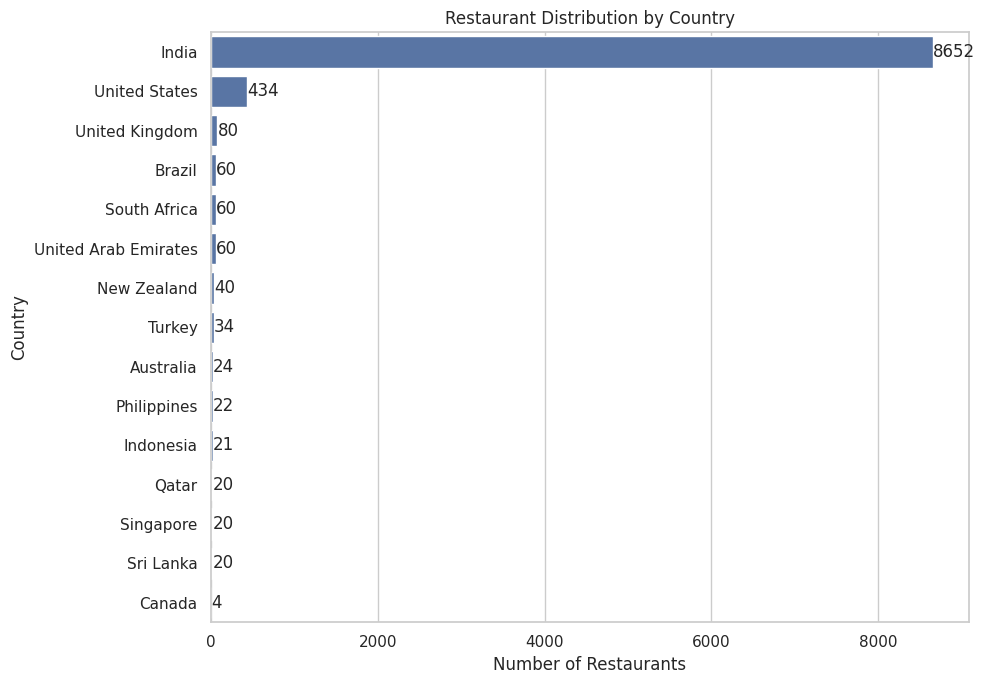

In [112]:
plt.figure(figsize=(10, 7))

ax = sns.countplot(
    data=df,
    y="Country",
    order=df["Country"].value_counts().index
)

plt.title("Restaurant Distribution by Country")
plt.xlabel("Number of Restaurants")
plt.ylabel("Country")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [113]:
city_distribution = df["City"].value_counts()

city_distribution.head(20)

,count
City,
New Delhi,5473
Gurgaon,1118
Noida,1080
Faridabad,251
Ghaziabad,25
Bhubaneshwar,21
Lucknow,21
Ahmedabad,21
Amritsar,21


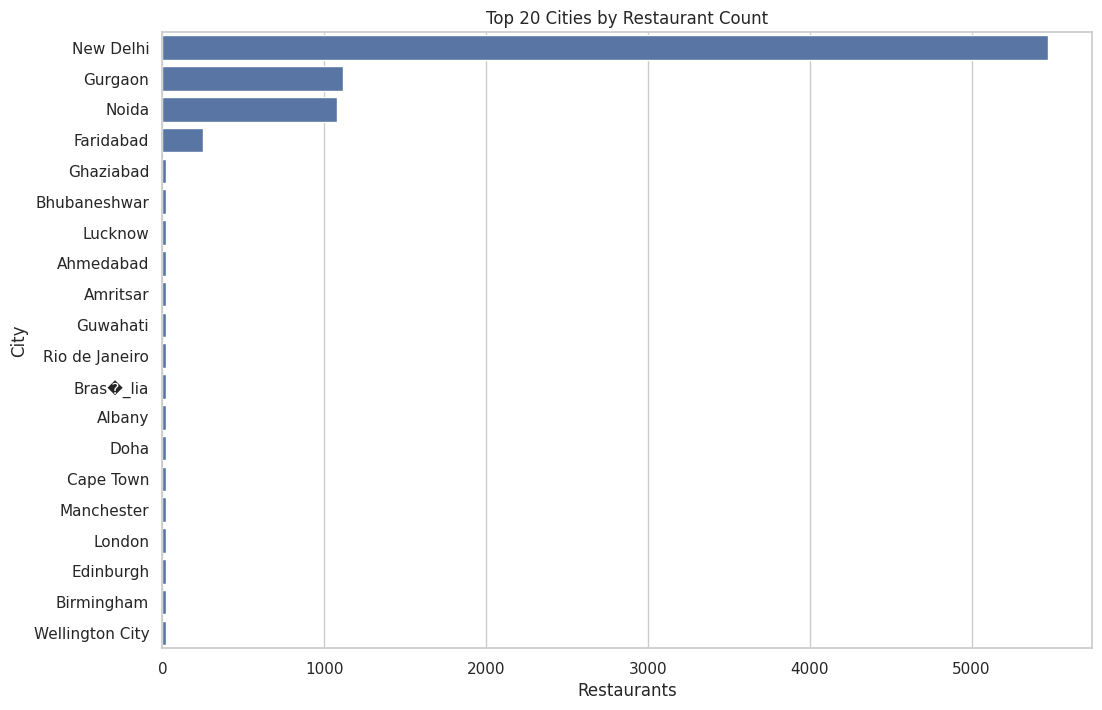

In [114]:
top20 = df["City"].value_counts().head(20)

plt.figure(figsize=(12,8))

sns.barplot(

x=top20.values,

y=top20.index

)

plt.title("Top 20 Cities by Restaurant Count")

plt.xlabel("Restaurants")

plt.ylabel("City")

plt.show()

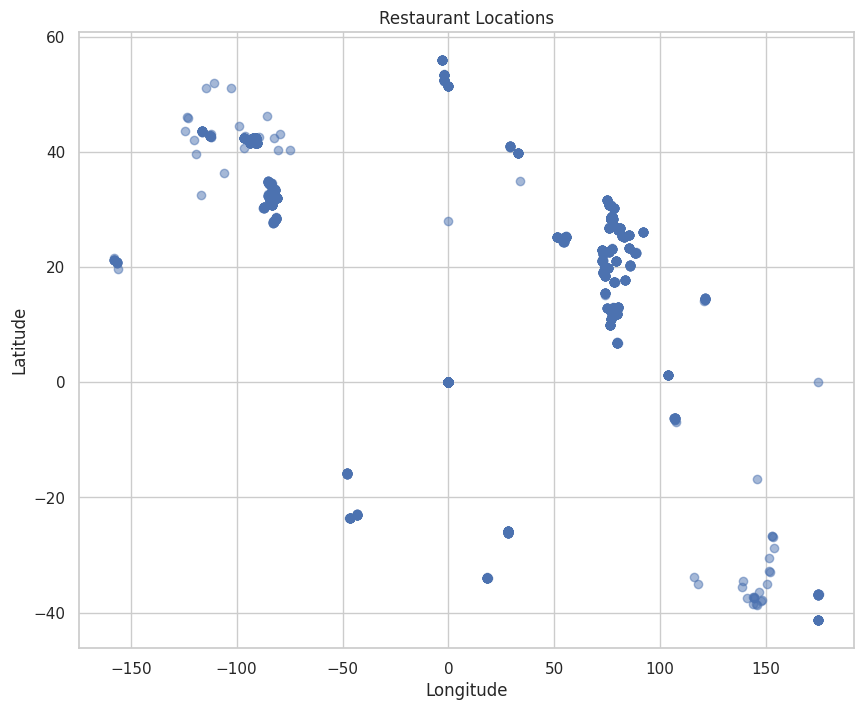

In [115]:
plt.figure(figsize=(10,8))

plt.scatter(

df["Longitude"],

df["Latitude"],

alpha=0.5

)

plt.xlabel("Longitude")

plt.ylabel("Latitude")

plt.title("Restaurant Locations")

plt.show()

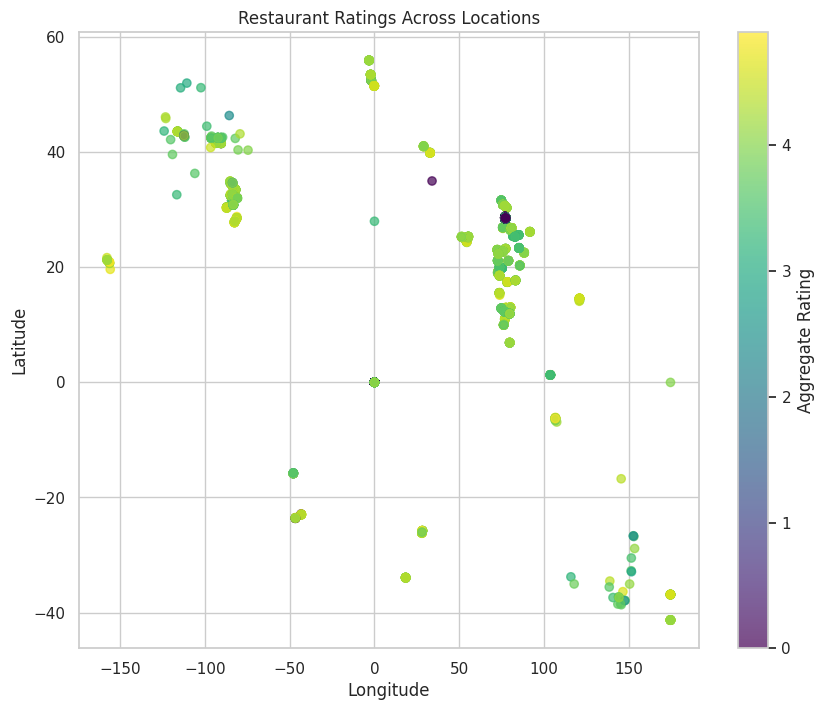

In [116]:
plt.figure(figsize=(10,8))

scatter = plt.scatter(

df["Longitude"],

df["Latitude"],

c=df["Aggregate rating"],

cmap="viridis",

alpha=0.7

)

plt.colorbar(scatter,label="Aggregate Rating")

plt.xlabel("Longitude")

plt.ylabel("Latitude")

plt.title("Restaurant Ratings Across Locations")

plt.show()

In [117]:
city_rating = (

df.groupby("City")["Aggregate rating"]

.mean()

.sort_values(ascending=False)

)

city_rating.head(20)

,Aggregate rating
City,
Inner City,4.900000
Quezon City,4.800000
Makati City,4.650000
Pasig City,4.633333
Mandaluyong City,4.625000
Beechworth,4.600000
London,4.535000
Taguig City,4.525000
Secunderabad,4.500000


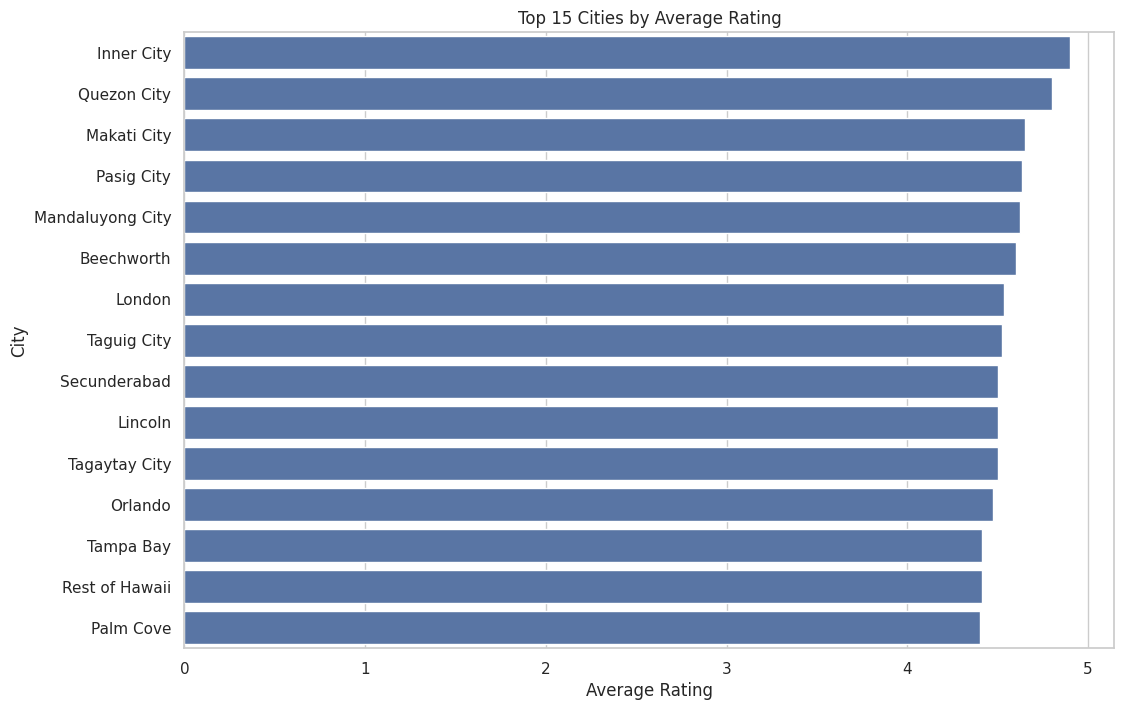

In [118]:
plt.figure(figsize=(12,8))

sns.barplot(

x=city_rating.head(15).values,

y=city_rating.head(15).index

)

plt.title("Top 15 Cities by Average Rating")

plt.xlabel("Average Rating")

plt.ylabel("City")

plt.show()

In [119]:
country_rating = (
    df.groupby("Country", observed=False)["Aggregate rating"]
    .mean()
    .sort_values(ascending=False)
)

country_rating

,Aggregate rating
Country,
Philippines,4.468182
Turkey,4.300000
Indonesia,4.295238
New Zealand,4.262500
United Arab Emirates,4.233333
South Africa,4.210000
United Kingdom,4.087500
Qatar,4.060000
United States,4.004378


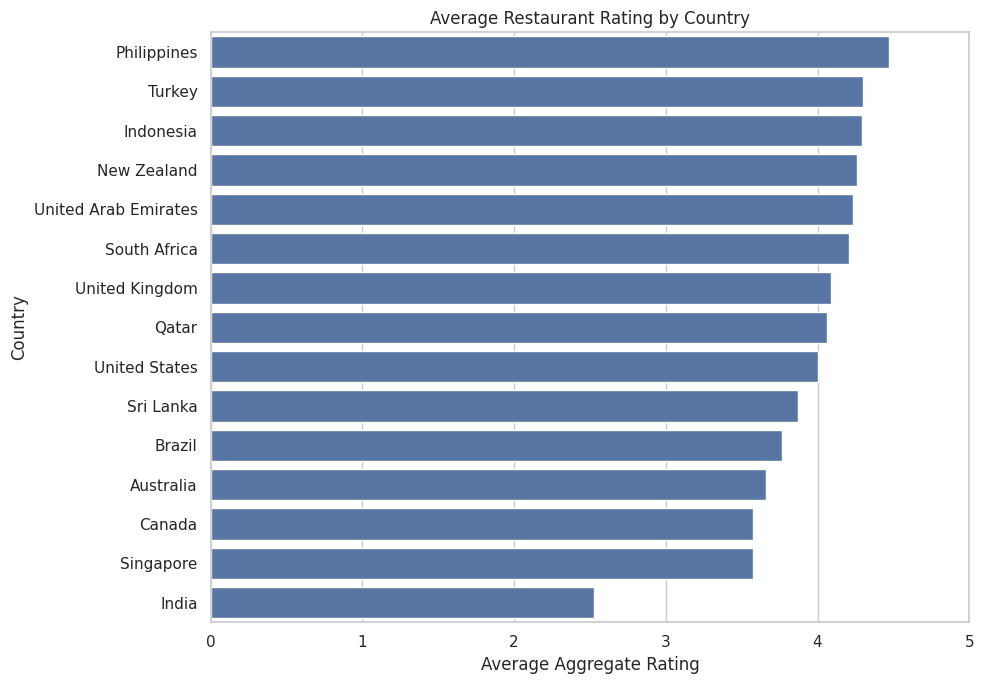

In [120]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=country_rating.values,
    y=country_rating.index
)

plt.title("Average Restaurant Rating by Country")
plt.xlabel("Average Aggregate Rating")
plt.ylabel("Country")
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

In [121]:
country_rating_summary = (
    df.groupby("Country", observed=False)
    .agg(
        Restaurant_Count=("Restaurant ID", "count"),
        Average_Rating=("Aggregate rating", "mean"),
        Total_Votes=("Votes", "sum")
    )
    .sort_values("Average_Rating", ascending=False)
    .round(2)
)

country_rating_summary

,Restaurant_Count,Average_Rating,Total_Votes
Country,,,
Philippines,22,4.47,8963
Turkey,34,4.30,14670
Indonesia,21,4.30,16214
New Zealand,40,4.26,9721
United Arab Emirates,60,4.23,29611
South Africa,60,4.21,18910
United Kingdom,80,4.09,16439
Qatar,20,4.06,3276
United States,434,4.00,185848


In [122]:
reliable_country_rating = country_rating_summary[
    country_rating_summary["Restaurant_Count"] >= 20
].sort_values("Average_Rating", ascending=False)

reliable_country_rating

,Restaurant_Count,Average_Rating,Total_Votes
Country,,,
Philippines,22,4.47,8963
Turkey,34,4.30,14670
Indonesia,21,4.30,16214
New Zealand,40,4.26,9721
United Arab Emirates,60,4.23,29611
South Africa,60,4.21,18910
United Kingdom,80,4.09,16439
Qatar,20,4.06,3276
United States,434,4.00,185848


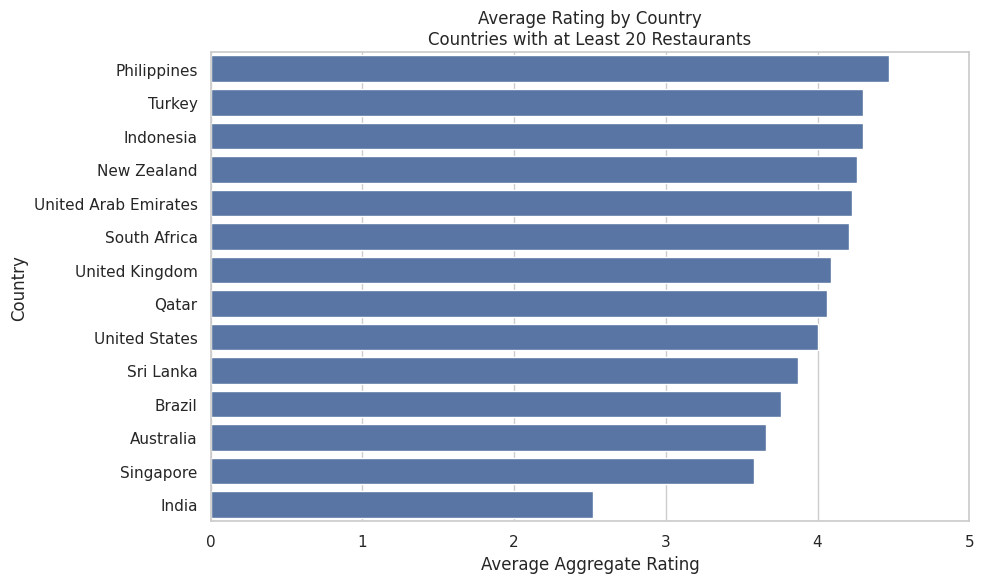

In [123]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=reliable_country_rating.reset_index(),
    x="Average_Rating",
    y="Country"
)

plt.title("Average Rating by Country\nCountries with at Least 20 Restaurants")
plt.xlabel("Average Aggregate Rating")
plt.ylabel("Country")
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

In [124]:
correlation = df[

["Latitude",

"Longitude",

"Aggregate rating"]

].corr()

correlation


,Latitude,Longitude,Aggregate rating
Latitude,1.000000,0.043207,0.000516
Longitude,0.043207,1.000000,-0.116818
Aggregate rating,0.000516,-0.116818,1.000000


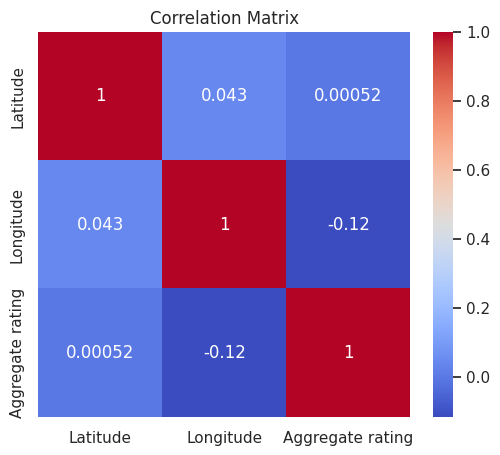

In [125]:
plt.figure(figsize=(6,5))

sns.heatmap(

correlation,

annot=True,

cmap="coolwarm"

)

plt.title("Correlation Matrix")

plt.show()

In [126]:
highest_rated = df.sort_values(

"Aggregate rating",

ascending=False

)

highest_rated[

["Restaurant Name",

"City",

"Country Code",

"Aggregate rating"]

].head(20)

,Restaurant Name,City,Country Code,Aggregate rating
8,Spiral - Sofitel Philippine Plaza Manila,Pasay City,162,4.9
10,Silantro Fil-Mex,Pasig City,162,4.9
3,Ooma,Mandaluyong City,162,4.9
9458,Urbanologi,Inner City,189,4.9
507,Mazzaro's Italian Market,Tampa Bay,216,4.9
509,Mr. Dunderbak's Biergarten and Marketplatz,Tampa Bay,216,4.9
429,Marukame Udon,Rest of Hawaii,216,4.9
428,Mama's Fish House,Rest of Hawaii,216,4.9
580,Punjab Grill,Abu Dhabi,214,4.9
589,AB's Absolute Barbecues,Dubai,214,4.9


In [127]:
df.to_csv("/content/Cleaned_Dataset_With_Country.csv", index=False)

print("Updated dataset saved successfully.")

Updated dataset saved successfully.


In [128]:
df = pd.read_csv("/content/Cleaned_Dataset_With_Country.csv")


In [129]:
df.to_csv("/content/Cleaned_Dataset.csv", index=False)

### Country Distribution Observation

The restaurant dataset contains records from 15 countries. India contributes the largest share of restaurants, meaning the dataset is heavily concentrated in the Indian market.

Because the country distribution is uneven, comparisons of average ratings should be interpreted carefully. Countries with only a small number of restaurants may show high or low average ratings that are not representative of a large market.

### Country Rating Observation

Average restaurant ratings vary across countries. However, countries with fewer restaurant records may have less reliable averages.

To make the comparison more meaningful, countries with at least 20 restaurants were also analyzed separately. This reduces the influence of very small sample sizes.

# Conclusion

Geospatial analysis revealed the geographical distribution of restaurants using latitude and longitude data. Interactive mapping and visualization highlighted restaurant concentration across different cities and countries.

Average ratings were compared across locations to identify regions with highly rated restaurants. Correlation analysis indicated that geographical coordinates alone do not strongly influence restaurant ratings.

The insights gained from this analysis can help businesses understand regional market concentration and identify potential expansion opportunities.